# Dynex SDK - Complex Native Gate Circuit Example

First we import the required packages:

In [1]:
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)


We define our circuit:

In [2]:
params = [0.1, 0.1, 0.2, 0.2, 0.3, 0.3, 0.4]
wires = 4


def Complex1(params):
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.RZ(params[2], wires=2)
    qml.RX(params[3], wires=3)
    qml.CZ(wires=[0, 2])
    qml.CRZ(params[4], wires=[1, 3])
    qml.Toffoli(wires=[0, 2, 3])
    qml.SWAP(wires=[0, 3])
    qml.SWAP(wires=[1, 2])
    qml.CRZ(params[5], wires=[3, 1])
    qml.CRY(params[6], wires=[2, 0])
    return qml.state()

We draw the circuit:

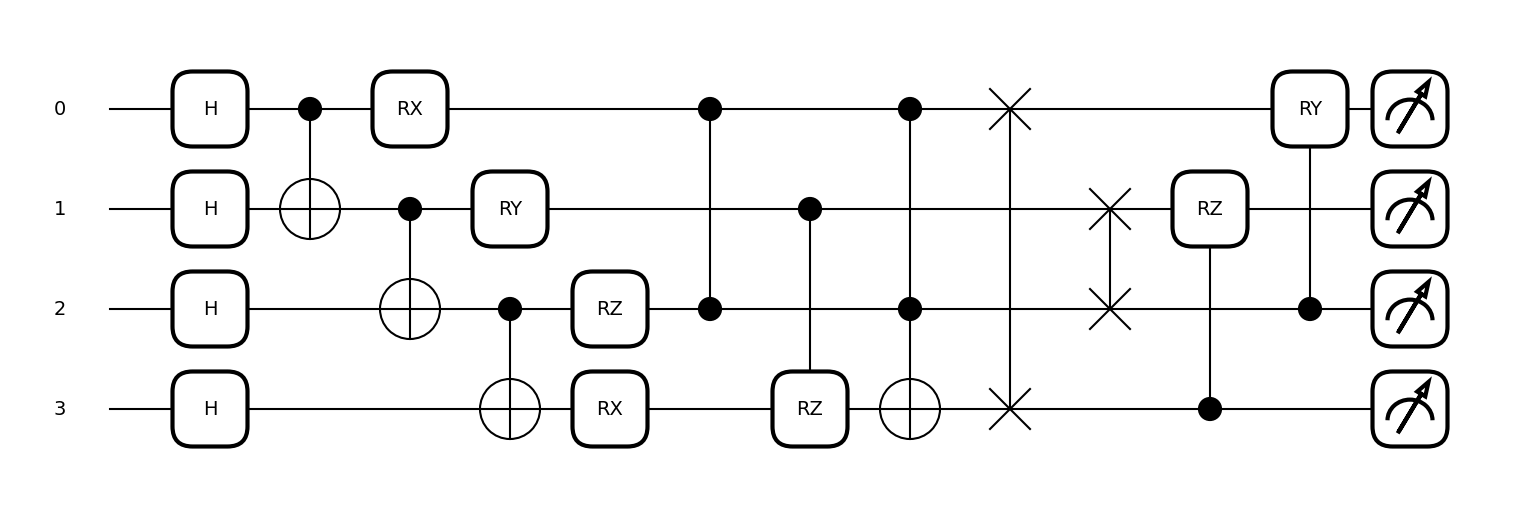

In [3]:
# draw circuit:
_ = qml.draw_mpl(Complex1, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(Complex1, params, wires, method="measure", num_reads=10,
                          integration_steps=100, shots=1)
print("Mesaure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=10, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7364)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_cry_2_0': 0.9800665778412416, 'cos_crz_1_3': 0.9887710779360422, 'cos_crz_3_1': 0.9887710779360422, 'cos_rx_0': 0.9987502603949663, 'cos_rx_3': 0.9950041652780258, 'cos_ry_1': 0.9987502603949663, 'cos_rz_2': 0.9950041652780258, 'sin_cry_2_0': 0.19866933079506122, 'sin_crz_1_3': 0.14943813247359922, 'sin_crz_3_1': 0.14943813247359922, 'sin_rx_0': 0.04997916927067833, 'sin_rx_3': 0.09983341664682815, 'sin_ry_1': 0.04997916927067833, 'sin_rz_2': 0.09983341664682815}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '1.0024979173609871', 'q': '789c9d59edaedb360c7d95fceb3a3486a82f4b7d99e022689702dd6e

Mesaure: [1 0 0 0]
